# Leontief Source Comparison

Compares predicted tariff pass-through to PCE prices under two Leontief inverse approaches:

- **Computed** — `(I - A)⁻¹` built from BEA Use Table 259
- **BEA** — pre-computed Commodity-by-Commodity Total Requirements (TableID 59)

As discussed, differences are driven by service-industry rows (wholesale/retail trade)
which have near-zero import shares and no tariff exposure. This notebook verifies
that the two approaches produce materially identical tariff predictions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import config
import pipeline

In [2]:
# ── Shared inputs (identical for both approaches) ─────────────────────────────
import_shares = pipeline.step1_import_shares(config.IO_YEAR, config.BEA_KEY)
delta_tariff_df = pipeline.step5_delta_tariff(
    config.IMPORTS_FILE, config.TARIFF_BASELINE_YEAR, config.TARIFF_CURRENT_MONTH
)
pce_bridge = pipeline.load_pce_bridge(config.IO_YEAR, config.BEA_KEY)

print(f"Commodities:     {len(import_shares)}")
print(f"BEA industries:  {len(delta_tariff_df)}")
print(f"PCE bridge rows: {len(pce_bridge)}")

Concordance built: 384/388 NAICS6 codes mapped to BEA IO industries
  Out of scope (services/unmapped): 4 codes
  BEA IO industries covered: 22

Import value coverage: 95.3% of total import value mapped to BEA IO industries

BEA IO industries with no tariff data (tau set to 0):
bea_io                      bea_desc
   213 Support activities for mining

Import value coverage: 94.2% of total import value mapped to BEA IO industries

BEA IO industries with no tariff data (tau set to 0):
bea_io                      bea_desc
   213 Support activities for mining
Commodities:     54
BEA industries:  24
PCE bridge rows: 297


In [3]:
# ── Build both Leontief inverses ──────────────────────────────────────────────
industries, A, L_computed = pipeline.step2_3_leontief(
    config.IO_YEAR, config.BEA_KEY, leontief_source="computed"
)
_, _, L_bea = pipeline.step2_3_leontief(
    config.IO_YEAR, config.BEA_KEY, leontief_source="bea"
)

print(f"\nMatrix shape: {L_computed.shape}")
print(f"L_computed diagonal mean: {np.diag(L_computed).mean():.4f}")
print(f"L_bea      diagonal mean: {np.diag(L_bea).mean():.4f}")

Leontief source: computed from (I - A)^{-1} via Use Table 259
Leontief source: BEA pre-computed Total Requirements (TableID 59)

Matrix shape: (68, 68)
L_computed diagonal mean: 1.1067
L_bea      diagonal mean: 1.0916


In [4]:
# ── Total import content: m_vec @ L ──────────────────────────────────────────
m_vec, m_total_computed = pipeline.step4_total_import_content(
    import_shares, industries, L_computed
)
_, m_total_bea = pipeline.step4_total_import_content(
    import_shares, industries, L_bea
)

print(f"Direct import share mean:         {m_vec.mean():.4f}")
print(f"Total import content — computed:  {m_total_computed.mean():.4f}")
print(f"Total import content — BEA:       {m_total_bea.mean():.4f}")
print(f"\nAmplification — computed: {m_total_computed.mean() / m_vec.mean():.2f}x")
print(f"Amplification — BEA:      {m_total_bea.mean() / m_vec.mean():.2f}x")

# Side-by-side for goods industries only (tariff-relevant)
goods_mask = [c in delta_tariff_df['bea_io'].values for c in industries]
goods_industries = [c for c, g in zip(industries, goods_mask) if g]
idx = [industries.index(c) for c in goods_industries]

compare_df = pd.DataFrame({
    'industry':          goods_industries,
    'direct_share':      m_vec[idx],
    'm_total_computed':  m_total_computed[idx],
    'm_total_bea':       m_total_bea[idx],
    'diff':              m_total_bea[idx] - m_total_computed[idx],
}).set_index('industry').sort_values('diff', ascending=False)

print(f"\nTotal import content — goods industries only:")
print(compare_df.to_string(float_format='{:.4f}'.format))

Direct import share mean:         0.0994
Total import content — computed:  0.2039
Total import content — BEA:       0.1792

Amplification — computed: 2.05x
Amplification — BEA:      1.80x

Total import content — goods industries only:
          direct_share  m_total_computed  m_total_bea    diff
industry                                                     
113FF           0.1987            0.2532       0.2522 -0.0010
334             0.5697            0.6796       0.6689 -0.0107
212             0.0549            0.1463       0.1313 -0.0151
339             0.4415            0.5588       0.5426 -0.0162
3364OT          0.1477            0.3223       0.3024 -0.0199
331             0.2401            0.4416       0.4197 -0.0219
213             0.0189            0.0861       0.0617 -0.0244
325             0.2919            0.4565       0.4312 -0.0253
315AL           0.8629            1.0046       0.9787 -0.0258
327             0.1603            0.2886       0.2576 -0.0310
211             0.316

In [5]:
# ── Predicted PCE effect under both approaches ────────────────────────────────
pce_computed = pipeline.step6_pce_effect(
    industries=industries, m_vec=m_vec, L=L_computed,
    delta_tariff_df=delta_tariff_df, pce_bridge=pce_bridge,
    markup=config.MARKUP_ASSUMPTION,
)
pce_bea = pipeline.step6_pce_effect(
    industries=industries, m_vec=m_vec, L=L_bea,
    delta_tariff_df=delta_tariff_df, pce_bridge=pce_bridge,
    markup=config.MARKUP_ASSUMPTION,
)

# Merge on PCE category
comparison = pce_computed[['PCE_category', 'predicted_effect', 'purchasers_value_total']].merge(
    pce_bea[['PCE_category', 'predicted_effect']],
    on='PCE_category', suffixes=('_computed', '_bea')
)
comparison['diff_pp'] = (
    comparison['predicted_effect_bea'] - comparison['predicted_effect_computed']
) * 100
comparison = comparison.sort_values('diff_pp', key=abs, ascending=False)

print(f"PCE categories compared: {len(comparison)}")
print(f"\nMax absolute difference: {comparison['diff_pp'].abs().max():.4f} pp")
print(f"Mean absolute difference: {comparison['diff_pp'].abs().mean():.4f} pp")
print(f"\nTop 20 categories by absolute difference (pp):")
print(
    comparison.head(20)[['PCE_category', 'predicted_effect_computed', 'predicted_effect_bea', 'diff_pp']]
    .assign(
        predicted_effect_computed=lambda x: x['predicted_effect_computed'] * 100,
        predicted_effect_bea=lambda x: x['predicted_effect_bea'] * 100,
    )
    .rename(columns={
        'predicted_effect_computed': 'computed (pp)',
        'predicted_effect_bea':      'bea (pp)',
        'diff_pp':                   'diff (pp)',
    })
    .to_string(index=False, float_format='{:.3f}'.format)
)

PCE categories compared: 76

Max absolute difference: 0.6766 pp
Mean absolute difference: 0.1262 pp

Top 20 categories by absolute difference (pp):
                                                          PCE_category  computed (pp)  bea (pp)  diff (pp)
                                                    New motor vehicles          4.802     4.125     -0.677
                                           Food furnished to employees          1.856     1.460     -0.396
                                      Sports and recreational vehicles          2.932     2.548     -0.384
                                   Food produced and consumed on farms          1.634     1.293     -0.341
                                   Motor vehicle parts and accessories          2.393     2.121     -0.271
                                                  Household appliances          4.224     3.953     -0.271
Food and nonalcoholic beverages purchased for off-premises consumption          1.221     0.961     -0.

In [6]:
# ── Weighted-average core goods effect ───────────────────────────────────────
def core_weighted_avg(pce_df):
    core = pce_df.query('PCE_category in @config.CORE_GOODS_CATEGORIES')
    return (
        (core['predicted_effect'] * core['purchasers_value_total']).sum()
        / core['purchasers_value_total'].sum()
    )

effect_computed = core_weighted_avg(pce_computed)
effect_bea      = core_weighted_avg(pce_bea)

print(f"Markup assumption: {config.MARKUP_ASSUMPTION}")
print(f"Weighted avg core goods effect — computed: {effect_computed:.3%}")
print(f"Weighted avg core goods effect — BEA:      {effect_bea:.3%}")
print(f"Difference:                                {(effect_bea - effect_computed)*100:+.3f} pp")

Markup assumption: constant_dollar
Weighted avg core goods effect — computed: 2.252%
Weighted avg core goods effect — BEA:      2.083%
Difference:                                -0.170 pp


c:\Users\micha\anaconda3\Lib\site-packages\matplotlib\collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor
c:\Users\micha\anaconda3\Lib\site-packages\matplotlib\collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


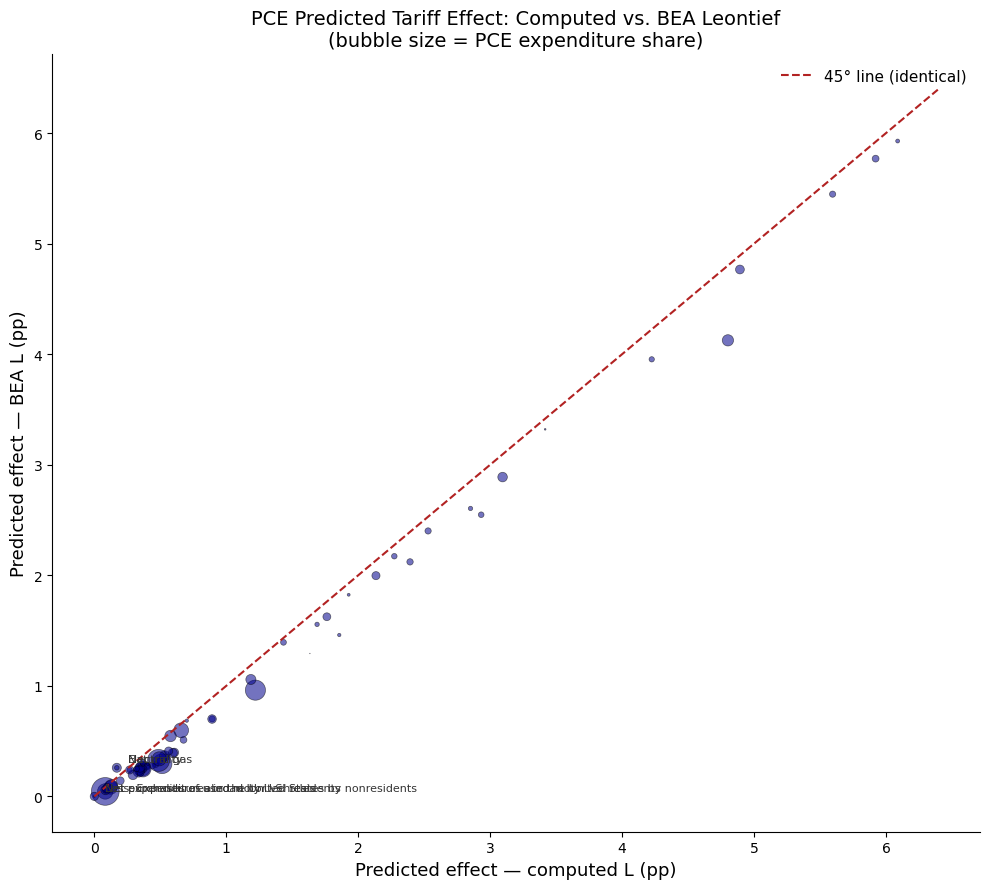

In [7]:
# ── Scatter: computed vs BEA predicted effect per PCE category ────────────────
plot_df = comparison.dropna(subset=['predicted_effect_computed', 'predicted_effect_bea'])
x = plot_df['predicted_effect_computed'] * 100
y = plot_df['predicted_effect_bea'] * 100
s = plot_df['purchasers_value_total'] / plot_df['purchasers_value_total'].max() * 400

fig, ax = plt.subplots(figsize=(10, 9))
ax.scatter(x, y, s=s, alpha=0.55, color='darkblue', edgecolors='black', linewidths=0.5)

# 45-degree line
lim = max(x.max(), y.max()) * 1.05
ax.plot([0, lim], [0, lim], color='firebrick', linewidth=1.5,
        linestyle='--', label='45° line (identical)')

# Label the largest outliers
top_outliers = comparison.nlargest(5, 'diff_pp')
for _, row in top_outliers.iterrows():
    ax.annotate(
        row['PCE_category'],
        xy=(row['predicted_effect_computed'] * 100, row['predicted_effect_bea'] * 100),
        xytext=(8, 4), textcoords='offset points',
        fontsize=8, color='#333333',
    )

ax.set_xlabel('Predicted effect — computed L (pp)', fontsize=13)
ax.set_ylabel('Predicted effect — BEA L (pp)', fontsize=13)
ax.set_title(
    'PCE Predicted Tariff Effect: Computed vs. BEA Leontief\n'
    '(bubble size = PCE expenditure share)',
    fontsize=14,
)
ax.legend(fontsize=11, frameon=False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()
plt.savefig('../figures/leontief_comparison_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

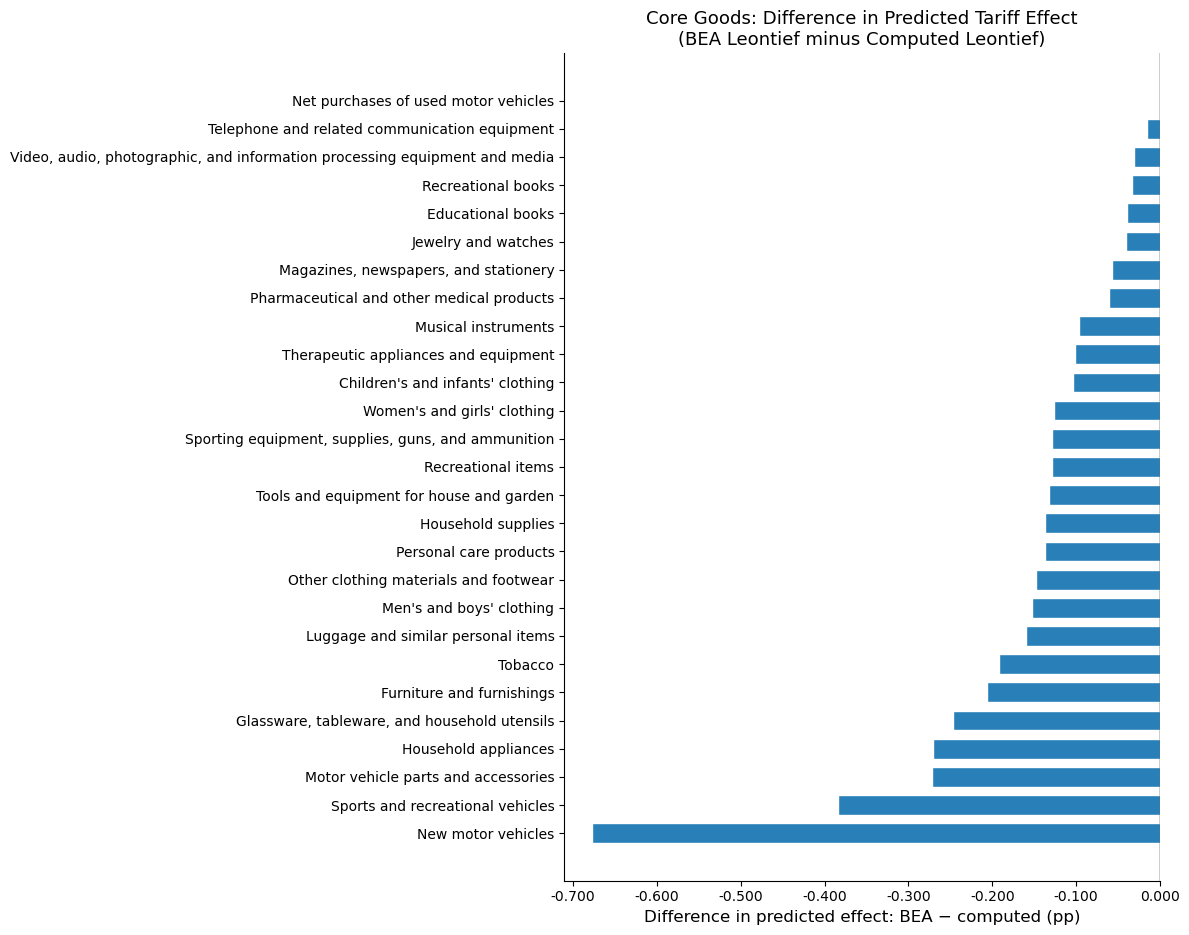

In [8]:
# ── Bar chart: difference (BEA − computed) per PCE category ──────────────────
bar_df = (
    comparison
    .query('PCE_category in @config.CORE_GOODS_CATEGORIES')
    .set_index('PCE_category')[['diff_pp']]
    .sort_values('diff_pp')
)

fig, ax = plt.subplots(figsize=(12, max(6, len(bar_df) * 0.35)))
colors = ['#c0392b' if v >= 0 else '#2980b9' for v in bar_df['diff_pp']]
ax.barh(bar_df.index, bar_df['diff_pp'], color=colors, edgecolor='white', height=0.7)
ax.axvline(0, color='black', linewidth=1)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
ax.set_xlabel('Difference in predicted effect: BEA − computed (pp)', fontsize=12)
ax.set_title(
    'Core Goods: Difference in Predicted Tariff Effect\n(BEA Leontief minus Computed Leontief)',
    fontsize=13,
)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()
plt.savefig('../figures/leontief_comparison_bars.png', dpi=150, bbox_inches='tight')
plt.show()